# TP 4 — Entraînement d'un LLM

Dans ce TP nous parcourons les étapes essentielles qui permettent à un modèle
de langage d'apprendre à générer du texte :

| Partie | Thème |
|:---:|---|
| 1 | Rappels machine learning — descente de gradient |
| 2 | Tokenisation — du texte aux IDs |
| 3 | Embedding — des IDs aux vecteurs |
| 4 | Softmax et température — des scores aux probabilités |
| 5 | Entraînement GRU — générer du texte à la Molière |
| 6 | Architecture Transformer — le moteur des LLMs modernes |
| 7 | Algèbre linéaire, GPU et géopolitique |

---

## Configuration de l'environnement

* Copier les fichiers de l'archive zip du TP dans le dosser `3_ia/tp4`
* Ouvrer le dossier du tp4 dans VS Code
* Ouvrir le terminal `View > Terminal`
* Executer `curl -LsSf https://astral.sh/uv/install.sh | sh` pour installer le manager d'environnement `uv`
* Fermer et ouvrez un nouveau terminal
* Executer `uv sync` pour installer tous les packages
* En haut à droite, cliquer sur `Select Kernel > Python Environment > ia-a-05`

---
## Partie 1 — Rappels machine learning

<u> modèle de jeu de donnée </u>

Nous allons partir d'un problème concret — **prédire le prix d'une maison** —
et le résoudre en trois étapes de complexité croissante :

$$\underbrace{1 \text{ feature}}_{\text{régression linéaire}} \;\to\; \underbrace{13 \text{ features}}_{\text{réseau dense}} \;\to\; \underbrace{\text{texte}}_{\text{GRU / Transformer}}$$

### 1.1 Le dataset — Boston Housing

Le dataset **Boston Housing** contient des informations sur 506 quartiers
de Boston (années 1970) avec 13 features et un prix médian en milliers de dollars.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import boston_housing

(x_train_full, y_train), (x_test, y_test) = boston_housing.load_data()

feature_names = [
    "CRIM",    # taux de criminalite
    "ZN",      # % terrains residentiels
    "INDUS",   # % zones industrielles
    "CHAS",    # bord de riviere (0/1)
    "NOX",     # concentration en oxydes d'azote
    "RM",      # nombre moyen de pieces  <- la plus correlee au prix
    "AGE",     # % maisons construites avant 1940
    "DIS",     # distance aux centres d'emploi
    "RAD",     # accessibilite aux autoroutes
    "TAX",     # taux d'imposition
    "PTRATIO", # ratio eleves/enseignant
    "B",       # indice demographique
    "LSTAT",   # % population a faible revenu
]

print(f"Train : {x_train_full.shape}  — {x_train_full.shape[0]} quartiers, {x_train_full.shape[1]} features")
print(f"Test  : {x_test.shape}")
print(f"Prix  : min={y_train.min():.1f} k$  max={y_train.max():.1f} k$  moyenne={y_train.mean():.1f} k$")
print()
print(f"  {'Feature':<10}  Quartier 0   Quartier 1")
print("-" * 35)
for name, v0, v1 in zip(feature_names, x_train_full[0], x_train_full[1]):
    print(f"  {name:<10}  {v0:>10.3f}   {v1:>10.3f}")

Train : (404, 13)  — 404 quartiers, 13 features
Test  : (102, 13)
Prix  : min=5.0 k$  max=50.0 k$  moyenne=22.4 k$

  Feature     Quartier 0   Quartier 1
-----------------------------------
  CRIM             1.232        0.022
  ZN               0.000       82.500
  INDUS            8.140        2.030
  CHAS             0.000        0.000
  NOX              0.538        0.415
  RM               6.142        7.610
  AGE             91.700       15.700
  DIS              3.977        6.270
  RAD              4.000        2.000
  TAX            307.000      348.000
  PTRATIO         21.000       14.700
  B              396.900      395.380
  LSTAT           18.720        3.110


### 1.2 Régression linéaire — 1 feature

On commence simplement : prédire le prix à partir du **nombre de pièces (RM)** seulement.

$$\hat{y} = f_\theta(x) = ax + b \qquad \theta = (a, b)$$

> x = nombre de pièce

>y = prix

>fonction f(x) = ax + b - donc paramère à estimer c'est a et b

> le modèle c'est la ligne - la droite, avec les paramètres a et b

> et lerreur c'est la distance des points à la droite- plutôt une fonction à la distance - (yi -f(x))^2
**Exercice 1.2** — Identifiez dans le code :
l'input $x$, l'output $y$, les paramètres $\theta$, la fonction de coût.

<u> voir le code </u>

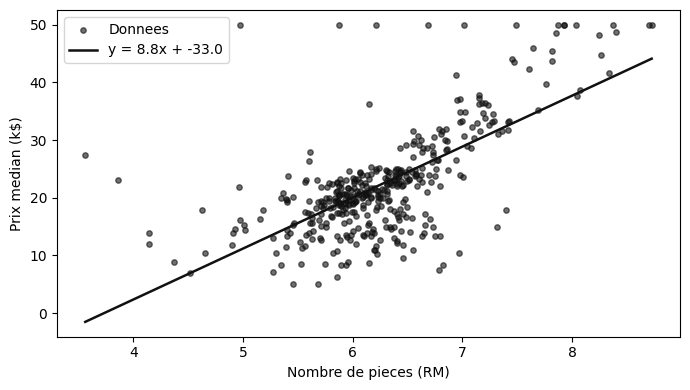

Parametres : a = 8.843  b = -33.026
MSE        : 45.32 k$**2


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#données de rentrées et sorties
x_rm   = x_train_full[:, 5]           # feature RM = nombre de pieces - INPUT : X
y      = y_train                       # prix en k$ 

a, b   = np.polyfit(x_rm, y, 1)       # solution analytique - PARAMèTRES A ET B => c'est ici le (yi -f(x))^2 - estimation - c'est ce qu'on fait au 1.3 - si on savait pas la formule

x_line = np.linspace(x_rm.min(), x_rm.max(), 200)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x_rm, y, color='#111111', s=15, alpha=0.6, zorder=3, label='Donnees') # fait les points. et la ligne de dessous fait la ligne
ax.plot(x_line, a*x_line + b, color='#111111', lw=1.8, #- la fonction de coût - a*x_line + b = c'est l'estimation - fait une droite - fait la moyenne de toutes les données qu'il reçoit en quelques sorte
        label=f'y = {a:.1f}x + {b:.1f}')
ax.set_xlabel('Nombre de pieces (RM)')
ax.set_ylabel('Prix median (k$)')
ax.legend()
plt.tight_layout()
plt.show()

mse = np.mean((a * x_rm + b - y) ** 2) # OUTPUT : Y 
print(f'Parametres : a = {a:.3f}  b = {b:.3f}')
print(f'MSE        : {mse:.2f} k$**2')

### 1.3 Surface de coût et descente de gradient

Plutôt que la solution analytique, un réseau de neurones **optimise itérativement** :

$$\theta \leftarrow \theta - \eta \cdot \nabla_\theta \mathcal{L}$$

Avec 2 paramètres $(a, b)$, on peut visualiser la **surface de coût** en 3D
et la trajectoire de l'optimisation.

In [14]:
import numpy as np
import plotly.graph_objects as go

x_rm = x_train_full[:, 5]
y    = y_train

x_n = (x_rm - x_rm.mean()) / x_rm.std()
y_n = (y    - y.mean())    / y.std()

# Descente de gradient manuelle
a, b = -1.5, 1.8
lr   = 0.06
traj = [(a, b)]
for _ in range(100):
    err = a * x_n + b - y_n
    a  -= lr * 2 / len(x_n) * (err @ x_n)
    b  -= lr * 2 / len(x_n) * err.sum()
    traj.append((a, b))

def mse(aa, bb):
    return np.mean((aa * x_n + bb - y_n) ** 2)

ag = np.linspace(-2.5, 2.5, 80)
bg = np.linspace(-2.5, 2.5, 80)
A, B = np.meshgrid(ag, bg)
Z    = np.vectorize(mse)(A, B)

ta, tb = zip(*traj)
tz     = [mse(a_, b_) for a_, b_ in traj]

fig = go.Figure()

# Surface de coût
fig.add_trace(go.Surface(
    x=ag, y=bg, z=Z,
    colorscale='gray', opacity=0.6,
    showscale=False,
))

# Trajectoire
fig.add_trace(go.Scatter3d(
    x=ta, y=tb, z=tz,
    mode='lines+markers',
    line=dict(color='black', width=4),
    marker=dict(size=3, color='black'),
    name='Trajectoire',
))

# Points départ / arrivée
fig.add_trace(go.Scatter3d(
    x=[ta[0], ta[-1]], y=[tb[0], tb[-1]], z=[tz[0], tz[-1]],
    mode='markers',
    marker=dict(size=8, color=['#AAAAAA', '#111111']),
    name='Départ / Arrivée',
))

fig.update_layout(
    scene=dict(
        xaxis_title='a',
        yaxis_title='b',
        zaxis_title='MSE',
        camera=dict(eye=dict(x=1.5, y=-1.8, z=1.0)),
    ),
    title='Surface de coût — RM → Prix (normalisé)',
    margin=dict(l=0, r=0, t=40, b=0),
    height=550,
)
fig.show()

# pour toutes les donneés - on fait la somme de (yi - f(xi)) ^2 - on remplace f() puis on dérive en fonciton de a et b - et donc ça nous donnes une estimes

**Exercice 1.3** — Répondez :

1. Que représente chaque point sur la trajectoire noire ?
2. Pourquoi la trajectoire descend-elle vers la zone sombre ?
3. Si on augmente `lr`, que se passe-t-il ?

*Votre réponse :*

1. <u>Les différents données - les estimations de a et b - c'est une étape - algo qui essaye de minimiser l'erreur </u>
2. <u>et on calculs l'erreur - donc le but c'est de se rapporcher de 0 - on fait estimation ça nous donne un point - on fait tangente dérivée - et on sait ou on doit s'orienter - les points suivent la tangentes pour se rapprocher de 0</u>

3.  c'est le pas entre chaque étapes - sintrop petit on fait des calculs pas nécessaire - perte de temps : si c'est top grand : en manquer le minimum à chaque fois on s'éloigne

### 1.4 Limites de la régression linéaire — passer à 13 features

Avec une seule feature `RM`, notre modèle est limité.
Visualisons la relation de chaque feature avec le prix :

> il y a tous les autres paramètres qui interviennent dans l'estimation du prix

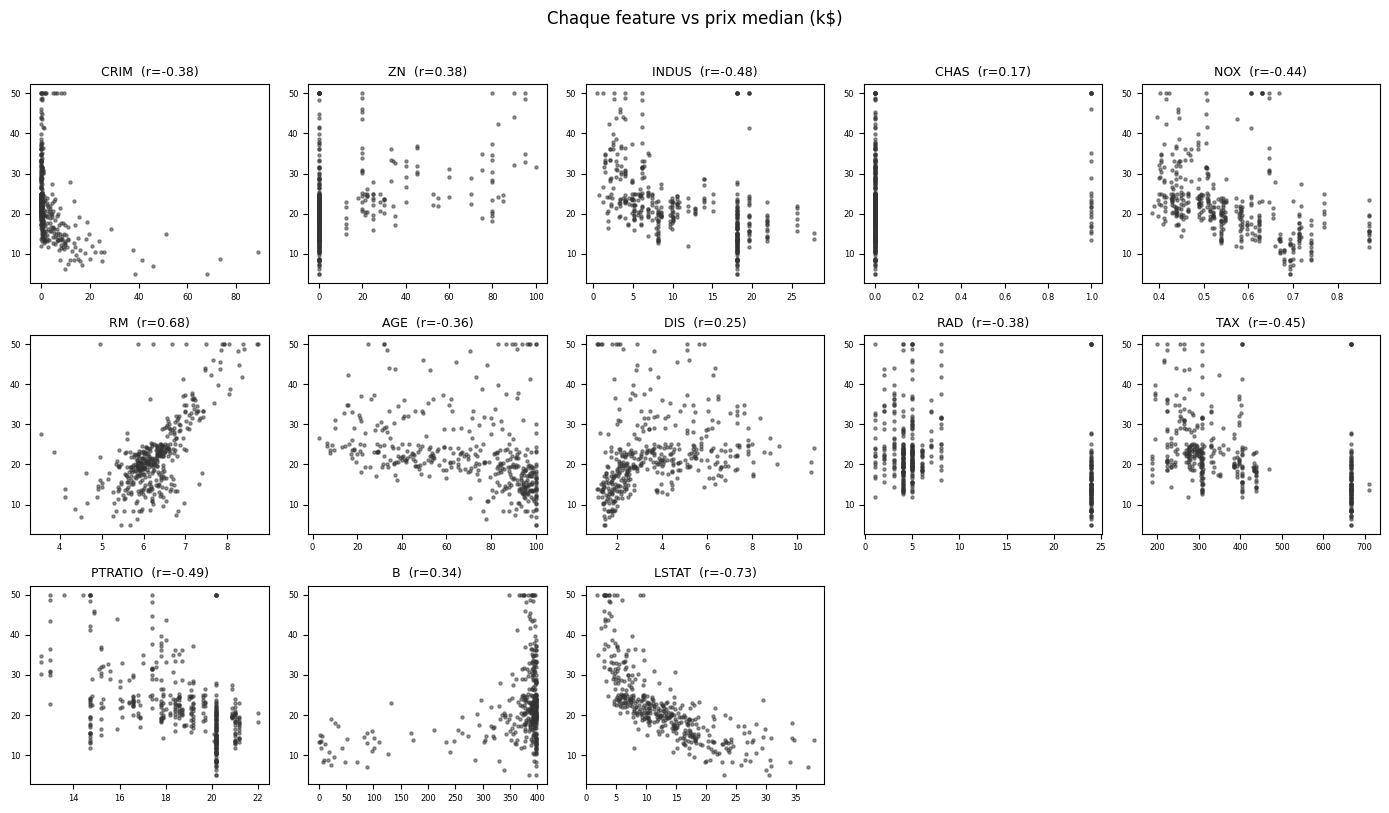

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = ["CRIM","ZN","INDUS","CHAS","NOX","RM",
                 "AGE","DIS","RAD","TAX","PTRATIO","B","LSTAT"]

fig, axes = plt.subplots(3, 5, figsize=(14, 8))
axes_flat = axes.flatten()

for i, (name, ax) in enumerate(zip(feature_names, axes_flat)):
    ax.scatter(x_train_full[:, i], y_train,
               color='#333333', s=5, alpha=0.5)
    r = np.corrcoef(x_train_full[:, i], y_train)[0, 1]
    ax.set_title(f"{name}  (r={r:.2f})", fontsize=9)
    ax.tick_params(labelsize=6)

for ax in axes_flat[13:]:
    ax.set_visible(False)

plt.suptitle("Chaque feature vs prix median (k$)", y=1.01)
plt.tight_layout()
plt.show()

# ce qui est affiché - c'est tous les rapport avec le prix - en axe y c'est le prix

### 1.5 Réseau dense — 13 features

**Problème** : avec 13 features, $\theta \in \mathbb{R}^{14}$ (13 poids + biais (paramètre b)).
La surface de coût est en **dimension 14** — impossible à visualiser.
Et une régression linéaire reste... linéaire, même en haute dimension.

**Solution** : un **réseau de neurones dense** avec des non-linéarités. <u> prend plusieurs données ? - paramètres - à vérifier /// il y a la présence de plusieurs neurones - et toutes les données sont connectées aux neurones - c'est le bordel - et entre chaque il y a les fonctions - ensuite depuis neurones - ça part dans estimation du prix</u>




#### 1.5.1 Réseau dense à une couche

$$x \in \mathbb{R}^{13} \xrightarrow{\text{Dense(64, relu)}}  \xrightarrow{\text{Dense(1)}} \hat{y} \in \mathbb{R}$$

##### Normalisation 

In [17]:
import keras
from keras import layers

# Normalisation des 13 features (chacune a sa propre echelle)
mean = x_train_full.mean(axis=0)
std  = x_train_full.std(axis=0)
x_train_n = (x_train_full - mean) / std
x_test_n  = (x_test       - mean) / std   # meme normalisation que le train !


Setup du modèle Keras

In [18]:
keras.utils.set_random_seed(42)
init = keras.initializers.RandomUniform(minval=-.5, maxval=.5, seed=42)

model_boston_1_couche = keras.Sequential([
    layers.Input(shape=(13,)), # représente les 13 entrées 
    layers.Dense(64, activation="relu", kernel_initializer=init), # les neurones : 64 => 13*64 = 832 et il faut encore additionné les biais donc  + 64 (neurones) =896 c'est ça l'estimation du nobre de paramètre pour la première couche
    # et pour la 2e couche - 64 neuronnes il y a +C => 65 paramètres- tableau du dessous résume
    layers.Dense(1, kernel_initializer=init),                       # pas d'activation : sortie continue
])
model_boston_1_couche.compile(optimizer="adam", loss="mse", metrics=["mae"])
model_boston_1_couche.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                896       
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 961 (3.75 KB)
Trainable params: 961 (3.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


2026-03-24 08:17:17.500377: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-03-24 08:17:17.500523: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-24 08:17:17.500529: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-03-24 08:17:17.500706: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-24 08:17:17.501010: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [19]:
# ce code c'est descente de gradiant - et ily a nombre de dimensions - 961 - total des paramètres
# époch
class AfficheEpoch(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:   # afficher toutes les 10 epochs
            print(f"Epoch {epoch+1:>3}  "
                  f"loss={logs['loss']:.2f}  "
                  f"val_loss={logs['val_loss']:.2f}  "
                  f"val_mae={logs['val_mae']:.2f} k$")

history_boston = model_boston_1_couche.fit(
    x_train_n, y_train,
    epochs=100, batch_size=16,
    validation_split=0.2,
    verbose=0,
    callbacks=[AfficheEpoch()]
)

mae = model_boston_1_couche.evaluate(x_test_n, y_test, verbose=0)[1]
print(f"Erreur absolue moyenne (test) : {mae:.2f} k$")

# Comparaison avec la regression lineaire sur RM
x_rm  = x_train_full[:, 5]
a_lin, b_lin = np.polyfit(x_rm, y_train, 1)
mse_lin = np.mean((a_lin * x_rm + b_lin - y_train) ** 2)
print(f"\nMSE regression lineaire (1 feature)  : {mse_lin:.2f} k$**2")
print(f"MSE reseau dense (13 features, val)   : {history_boston.history['val_loss'][-1]:.2f} k$**2")

2026-03-24 08:17:22.375596: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Epoch  10  loss=399.14  val_loss=438.36  val_mae=19.57 k$
Epoch  20  loss=220.07  val_loss=234.37  val_mae=13.70 k$
Epoch  30  loss=99.72  val_loss=101.86  val_mae=7.97 k$
Epoch  40  loss=51.00  val_loss=49.91  val_mae=4.97 k$
Epoch  50  loss=34.16  val_loss=32.94  val_mae=4.06 k$
Epoch  60  loss=28.19  val_loss=27.23  val_mae=3.68 k$
Epoch  70  loss=25.71  val_loss=25.78  val_mae=3.63 k$
Epoch  80  loss=24.35  val_loss=25.39  val_mae=3.63 k$
Epoch  90  loss=23.52  val_loss=24.07  val_mae=3.52 k$
Epoch 100  loss=23.26  val_loss=23.42  val_mae=3.48 k$
Erreur absolue moyenne (test) : 3.37 k$

MSE regression lineaire (1 feature)  : 45.32 k$**2
MSE reseau dense (13 features, val)   : 23.42 k$**2


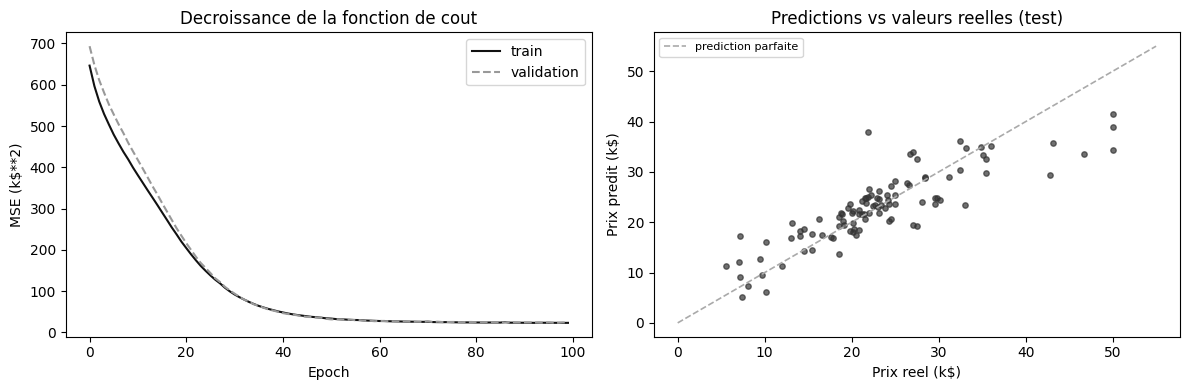

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Courbes de loss
axes[0].plot(history_boston.history["loss"],     color='#111111', lw=1.5, label='train')
axes[0].plot(history_boston.history["val_loss"], color='#999999', lw=1.5, ls='--', label='validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE (k$**2)')
axes[0].set_title('Decroissance de la fonction de cout')
axes[0].legend()

# Predictions vs valeurs reelles
y_pred = model_boston_1_couche.predict(x_test_n, verbose=0).flatten()
axes[1].scatter(y_test, y_pred, color='#333333', s=15, alpha=0.7)
lims = [0, 55]
axes[1].plot(lims, lims, color='#AAAAAA', lw=1.2, ls='--', label='prediction parfaite')
axes[1].set_xlabel('Prix reel (k$)')
axes[1].set_ylabel('Prix predit (k$)')
axes[1].set_title('Predictions vs valeurs reelles (test)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# tellement il sont entrainé - overfit - donc par la suite incapable de traiter d'aures données - ils apprennent le par coeur - s'il y a trop de donneés


#### 1.5.2 Réseau dense à deux couches


$$x \in \mathbb{R}^{13} \xrightarrow{\text{Dense(64, relu)}} \xrightarrow{\text{Dense(64, relu)}} \xrightarrow{\text{Dense(1)}} \hat{y} \in \mathbb{R}$$


même principe que dans l'autre mais on rajoute une couche avant la sortie - donc les neuronnes de la première ligne se connectent à tous ceux de la 2e - regarder tableau

In [21]:
model_boston_2_couches = keras.Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1),                       # pas d'activation : sortie continue
])
model_boston_2_couches.compile(optimizer="adam", loss="mse", metrics=["mae"])
model_boston_2_couches.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 64)                896       
                                                                 
 dense_3 (Dense)             (None, 64)                4160      
                                                                 
 dense_4 (Dense)             (None, 1)                 65        
                                                                 
Total params: 5121 (20.00 KB)
Trainable params: 5121 (20.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [22]:
history_boston = model_boston_2_couches.fit(
    x_train_n, y_train,
    epochs=100, batch_size=16,
    validation_split=0.2,
    verbose=0
)

mae = model_boston_2_couches.evaluate(x_test_n, y_test, verbose=0)[1]
print(f"Erreur absolue moyenne (test) : {mae:.2f} k$")

# Comparaison avec la regression lineaire sur RM
x_rm  = x_train_full[:, 5]
a_lin, b_lin = np.polyfit(x_rm, y_train, 1)
mse_lin = np.mean((a_lin * x_rm + b_lin - y_train) ** 2)
print(f"\nMSE regression lineaire (1 feature)  : {mse_lin:.2f} k$**2")
print(f"MSE reseau dense (13 features, val)   : {history_boston.history['val_loss'][-1]:.2f} k$**2")

Erreur absolue moyenne (test) : 3.71 k$

MSE regression lineaire (1 feature)  : 45.32 k$**2
MSE reseau dense (13 features, val)   : 41.90 k$**2


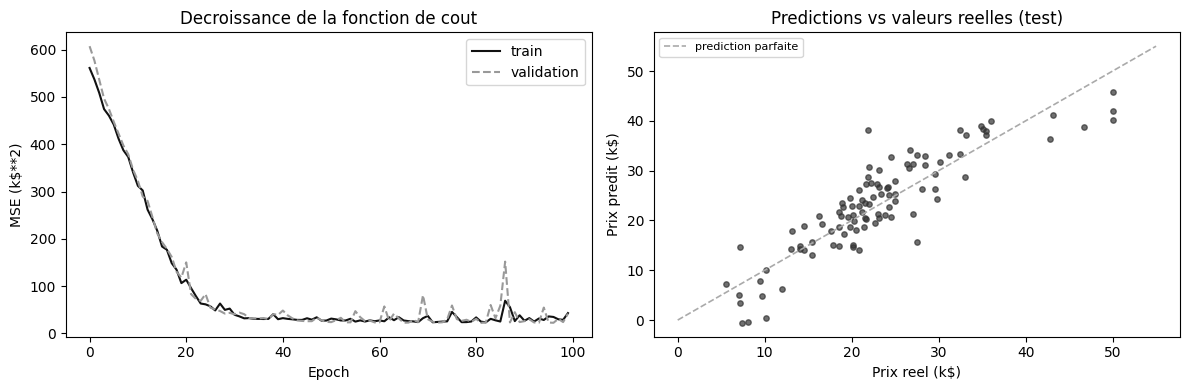

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Courbes de loss
axes[0].plot(history_boston.history["loss"],     color='#111111', lw=1.5, label='train')
axes[0].plot(history_boston.history["val_loss"], color='#999999', lw=1.5, ls='--', label='validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE (k$**2)')
axes[0].set_title('Decroissance de la fonction de cout')
axes[0].legend()

# Predictions vs valeurs reelles
y_pred = model_boston_2_couches.predict(x_test_n, verbose=0).flatten()
axes[1].scatter(y_test, y_pred, color='#333333', s=15, alpha=0.7)
lims = [0, 55]
axes[1].plot(lims, lims, color='#AAAAAA', lw=1.2, ls='--', label='prediction parfaite')
axes[1].set_xlabel('Prix reel (k$)')
axes[1].set_ylabel('Prix predit (k$)')
axes[1].set_title('Predictions vs valeurs reelles (test)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Exercice 1.5** :

1. Pourquoi normalise-t-on les features avant d'entraîner le réseau ?
2. Pourquoi la dernière couche `Dense(1)` n'a-t-elle pas de fonction d'activation ?
   Que se passerait-il avec `relu` ?
3. Le réseau dense bat-il la régression linéaire ? De combien ?
4. Sur le graphe prédictions vs réalité, y a-t-il des zones où le modèle
   se trompe plus ? Pourquoi selon vous ?

*Votre réponse :*
1. 
2. 
3. 
4. 

---
## Partie 2 — Tokenisation

Un LLM ne travaille pas directement sur des caractères ou des mots :
il transforme d'abord le texte en une séquence d'entiers appelés **tokens**.

Trois stratégies principales, du plus simple au plus sophistiqué.


> avant on disait juste que il y a rentré c'était un nombre et sortie c'est un nombre, maintenant comment faire pour donner texte et faire sortir un texte, sachant que c'est des nombres entres 2

> on veut sortir la probabilité des token qui suivent - on fait la distibution de probabilité conditionnel

> il y a deux étapes pour passer de texte à nombre - arrivée au début du réseau neurones - tokenisation et embedding

### 2.1 Tokenisation par caractère

In [24]:
texte = "Couvrez ce sein que je ne saurais voir. Par de pareils objets les âmes sont blessées, Et cela fait venir de coupables pensées."

vocab      = sorted(set(texte))
char_to_id = {c: i for i, c in enumerate(vocab)}
id_to_char = {i: c for c, i in char_to_id.items()}
tokens     = [char_to_id[c] for c in texte]

print(f"Taille du vocabulaire : {len(vocab)} caractères")
print(f"Vocabulaire           : {vocab}")
print()
print(f"Texte     : {texte[:25]}...")
print(f"Token IDs : {tokens[:25]}...")
# divisé texte en lettre

Taille du vocabulaire : 28 caractères
Vocabulaire           : [' ', ',', '.', 'C', 'E', 'P', 'a', 'b', 'c', 'd', 'e', 'f', 'i', 'j', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'z', 'â', 'é']

Texte     : Couvrez ce sein que je ne...
Token IDs : [3, 17, 23, 24, 20, 10, 25, 0, 8, 10, 0, 21, 10, 12, 16, 0, 19, 23, 10, 0, 13, 10, 0, 16, 10]...


### 2.2 Tokenisation par mot

In [25]:
# faire par mot
import re

mots      = re.findall(r"[\w'éèêëàâùûîïôœç]+|[.,!?;]", texte)
vocab_m   = sorted(set(mots))
mot_to_id = {m: i for i, m in enumerate(vocab_m)}
tokens_m  = [mot_to_id[m] for m in mots]

print(f"Taille du vocabulaire : {len(vocab_m)} mots")
print(f"Vocabulaire           : {vocab_m}")
print()
print(f"Mots      : {mots[:10]}")
print(f"Token IDs : {tokens_m[:10]}")

Taille du vocabulaire : 24 mots
Vocabulaire           : [',', '.', 'Couvrez', 'Et', 'Par', 'blessées', 'ce', 'cela', 'coupables', 'de', 'fait', 'je', 'les', 'ne', 'objets', 'pareils', 'pensées', 'que', 'saurais', 'sein', 'sont', 'venir', 'voir', 'âmes']

Mots      : ['Couvrez', 'ce', 'sein', 'que', 'je', 'ne', 'saurais', 'voir', '.', 'Par']
Token IDs : [2, 6, 19, 17, 11, 13, 18, 22, 1, 4]


### 2.3 Tokenisation BPE — le tokenizer de GPT-4

**BPE (Byte-Pair Encoding)** fusionne itérativement les paires de caractères
les plus fréquentes pour former un vocabulaire de sous-mots.
GPT-4 utilise le tokenizer `cl100k_base` : ~100 000 tokens.

In [ ]:
# celle qui est le plus utilisé - par caractère ou par mot ?
import tiktoken

enc = tiktoken.get_encoding("cl100k_base")   # tokenizer de GPT-4

exemples = [
    "Morbleu", "Palsambleu", "Diantre", "Peste",
     "Coeur", "raison", "imposteur", "médecin", "ridicule", "mariage", "honnête homme",
     "King", "Hello", "the", "Obama", "Napoleon",
     "Germany", "scientific", "rendering", "tokenization", "tokenizer", "artificial intelligence"
]

print(f"{'Texte':<38} {'N':>4}  Découpage BPE")
print("-" * 80)
for t in exemples:
    ids      = enc.encode(t)
    morceaux = [enc.decode([i]) for i in ids]
    print(f"{t:<38} {len(ids):>4}  {morceaux}")

: 

**Exercice 2.3** :

tokenisation : but c'est de créer un dictionnaire - token 1, token 2, ...

si c'est par BPE : sort bout de mot - par exemple c'est ce que fait ChatGPT

si c'est un mot très courant - il va venir entier et s'il est rare il vient séparer

entraîner selon langue





---

1. Comparez le nombre de tokens pour les phrases française et anglaise
   équivalentes. Quelle langue est avantagée ? Pourquoi ?

   L'anglais est avantagé, car la majorité du temps tout le mot est compris dans le token
2. Complétez ce tableau :

| | Par caractère | Par mot | BPE |
|---|:---:|:---:|:---:|
| Taille du vocabulaire | ~100 | ~100 000+ | ~50–100 k |
| Longueur des séquences | longue | ***✓ ?*** | ***✓ ?*** |
| Gère les mots inconnus | ✓ | ***?*** | ***✓ ?*** |
| Utilisé par les LLMs | ✗ | ✗ | ✓ |

3. Trouvez un mot français découpé en 3 tokens ou plus :

In [27]:
# Votre exploration — ajoutez des mots à tester
mots_a_tester = [
    "anticonstitutionnellement",
    # Ajoutez vos mots ici :
]

for mot in mots_a_tester:
    ids      = enc.encode(mot)
    morceaux = [enc.decode([i]) for i in ids]
    print(f"{mot!r:<30} → {len(ids)} token(s) : {morceaux}")

NameError: name 'enc' is not defined

---
## Partie 3 — Embedding


> comment passer de nombre à texte - vers la sortie


Chaque token ID est converti en un **vecteur de dimension $d$** :

$$\text{token\_id} \;\xrightarrow{\text{table d'embedding}}\; \vec{v} \in \mathbb{R}^d$$

Ces vecteurs sont appris pendant l'entraînement : des tokens sémantiquement
proches se retrouvent proches dans l'espace vectoriel.

### 3.1 Chargement des embeddings GloVe

In [28]:
import gensim.downloader as api

# GloVe entraîné sur Wikipedia + Gigaword — dimension 100 — ~66 MB
print("Chargement des embeddings GloVe...")
wv = api.load("glove-wiki-gigaword-100")
print(f"Modèle chargé : {len(wv):,} mots, dimension {wv.vector_size}")
print(f"\nVecteur de 'king' (10 premières dimensions) :")
print(wv['king'][:10])

Chargement des embeddings GloVe...
Modèle chargé : 400,000 mots, dimension 100

Vecteur de 'king' (10 premières dimensions) :
[-0.32307 -0.87616  0.21977  0.25268  0.22976  0.7388  -0.37954 -0.35307
 -0.84369 -1.1113 ]


### 3.2 Similarité cosinus

La distance entre deux vecteurs mesure la **similarité sémantique** :

$$\text{sim}(\vec{u}, \vec{v}) = \frac{\vec{u} \cdot \vec{v}}{\|\vec{u}\| \cdot \|\vec{v}\|} \in [-1, 1]$$

In [29]:
for mot in ["king", "paris", "computer", "love", "war"]:
    voisins = wv.most_similar(mot, topn=5)
    noms    = [f"{m}({s:.2f})" for m, s in voisins]
    print(f"{mot:12s} → {', '.join(noms)}")


# calcul entre deux vecteurs

king         → prince(0.77), queen(0.75), son(0.70), brother(0.70), monarch(0.70)
paris        → prohertrib(0.80), france(0.75), london(0.73), brussels(0.70), french(0.69)
computer     → computers(0.88), software(0.84), technology(0.76), pc(0.74), hardware(0.73)
love         → me(0.74), passion(0.74), my(0.73), life(0.73), dream(0.73)
war          → wars(0.77), conflict(0.77), invasion(0.74), military(0.74), occupation(0.73)


### 3.3 Arithmétique vectorielle

Les **relations sémantiques** se traduisent en **opérations vectorielles** :

$$\vec{\text{king}} - \vec{\text{man}} + \vec{\text{woman}} \approx \vec{\text{queen}}$$

Cette propriété émerge spontanément de l'entraînement sur du texte.

In [30]:
analogies = [
    ("king",   "man",    "woman",   "queen"),
    ("paris",  "france", "germany", "berlin"),
    ("walked", "walk",   "run",     "ran"), # prendre un verbe au passé - en enlève celui à l'infinitif et on rajoute un autre verbe 
    ("doctor", "man",    "woman",   "nurse"),
]

print(f"{'Opération':<32} {'Attendu':<10} {'Top 3 résultats'}")
print("-" * 72)
for A, B, C, attendu in analogies:
    res = wv.most_similar(positive=[A, C], negative=[B], topn=3)
    top = [f"{m}({s:.2f})" for m, s in res]
    ok  = "✓" if attendu in [r[0] for r in res] else "✗"
    print(f"{A} − {B} + {C} = ? {ok}   {attendu:<10} {', '.join(top)}")

Opération                        Attendu    Top 3 résultats
------------------------------------------------------------------------
king − man + woman = ? ✓   queen      queen(0.77), monarch(0.68), throne(0.68)
paris − france + germany = ? ✓   berlin     berlin(0.88), frankfurt(0.80), vienna(0.77)
walked − walk + run = ? ✓   ran        went(0.71), drove(0.71), ran(0.71)
doctor − man + woman = ? ✓   nurse      nurse(0.77), physician(0.72), doctors(0.68)


**Exercice 3.3** — Inventez 2 nouvelles analogies et testez-les :

In [31]:
mes_analogies = [
    #(A,    B,     C,     attendu),
    # ("...", "...", "...", "..."),
    ("king",   "man",    "woman",   "queen"),
    ("doctor", "man",    "woman",   "nurse")
]

for A, B, C, attendu in mes_analogies:
    res = wv.most_similar(positive=[A, C], negative=[B], topn=3)
    top = [f"{m}({s:.2f})" for m, s in res]
    ok  = "✓" if attendu in [r[0] for r in res] else "✗"
    print(f"{A} − {B} + {C} = ? {ok}  {attendu:<10} {', '.join(top)}")

king − man + woman = ? ✓  queen      queen(0.77), monarch(0.68), throne(0.68)
doctor − man + woman = ? ✓  nurse      nurse(0.77), physician(0.72), doctors(0.68)


### 3.4 Visualisation 2D (PCA)

Les vecteurs d'embedding sont en dimension 100. On les projette en 2D
avec une **ACP** pour les visualiser.

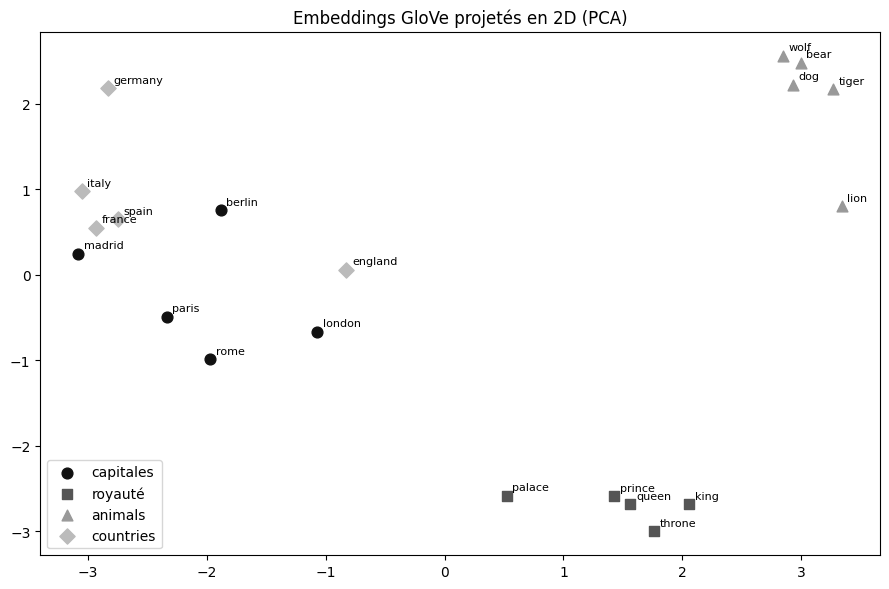

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

groupes = {
    "capitales": ["paris", "berlin", "rome", "madrid", "london"],
    "royauté"  : ["king", "queen", "prince", "palace", "throne"],
    "animals"   : ["lion", "tiger", "bear", "wolf", "dog"],
    "countries" : ["france", "germany", "italy", "spain", "england"],
}

couleurs = ["#111111", "#555555", "#999999", "#BBBBBB"]
markers  = ["o", "s", "^", "D"]

mots_all = [m for g in groupes.values() for m in g]
vecs     = np.array([wv[m] for m in mots_all])
coords   = PCA(n_components=2).fit_transform(vecs)

fig, ax = plt.subplots(figsize=(9, 6))
i = 0
for (nom, mots_g), col, mk in zip(groupes.items(), couleurs, markers):
    n = len(mots_g)
    ax.scatter(coords[i:i+n, 0], coords[i:i+n, 1],
               color=col, marker=mk, s=60, label=nom, zorder=3)
    for j, mot in enumerate(mots_g):
        ax.annotate(mot, coords[i+j], fontsize=8,
                    xytext=(4, 4), textcoords='offset points')
    i += n

ax.set_title('Embeddings GloVe projetés en 2D (PCA)')
ax.legend()
plt.tight_layout()
plt.show()

# c'est pas exactement ChatGPT - il a en plus le contexte tout autour de ces mots

**Exercice 3.4** :

1. Les mots du même groupe sont-ils proches dans l'espace 2D ?
2. La relation *pays → capitale* forme-t-elle un motif régulier ?
   Comparez par exemple `france`→`paris` et `germany`→`berlin`.
3. Ajoutez un groupe de votre choix dans `groupes` et relancez la cellule.

*Votre réponse :*

---
## Partie 4 — Softmax et température

La dernière couche d'un LLM produit un vecteur de **logits** (un score brut
par token du vocabulaire). La fonction **softmax** convertit ces scores en
distribution de probabilité :

$$\text{softmax}(z_i) = \frac{e^{z_i / T}}{\displaystyle\sum_j e^{z_j / T}}$$

Le paramètre $T$ (température) contrôle la « netteté » de la distribution.

### 4.1 Effet de la température

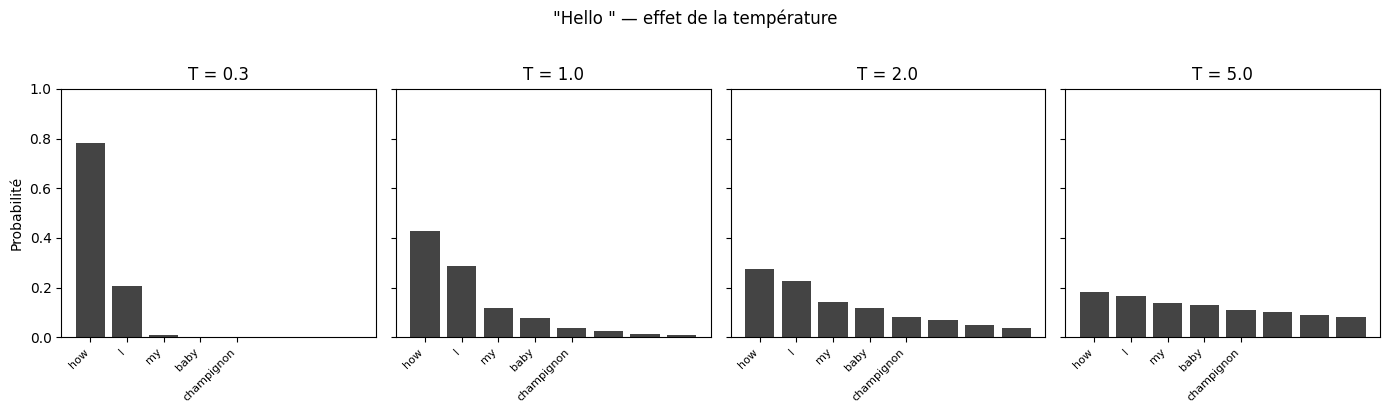

In [35]:
import numpy as np
import matplotlib.pyplot as plt

candidats = ["how", "I", "my", "baby", "champignon"]
logits    = np.array([3.2, 2.8, 1.9, 1.5, 0.8, 0.4, -0.2, -0.8])

def softmax(z, T=1.0):
    e = np.exp((z - z.max()) / T)   # décalage pour stabilité numérique
    return e / e.sum()

temperatures = [0.3, 1.0, 2.0, 5.0]
fig, axes    = plt.subplots(1, 4, figsize=(14, 4), sharey=True)

for ax, T in zip(axes, temperatures):
    probs = softmax(logits, T)
    ax.bar(range(len(probs)), probs, color='#444444')
    ax.set_xticks(range(len(candidats)))
    ax.set_xticklabels(candidats, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'T = {T}')
    ax.set_ylim(0, 1)
    if ax is axes[0]:
        ax.set_ylabel('Probabilité')

plt.suptitle('"Hello " — effet de la température', y=1.02)
plt.tight_layout()
plt.show()

**Exercice 4.1** :

1. Que se passe-t-il quand $T \to 0$ ? Quel type de texte obtient-on ?
2. Que se passe-t-il quand $T \to \infty$ ?
3. Quelle température semble adaptée pour un chatbot ? Pour un générateur de poésie ?

*Votre réponse :*
1. ***le texte est clair - car c'est le mot le plus probable qui vient juste après*** - toujours même mots qui ressort
2. ***le texte devient incompréhensible***
3. ***chatbot : température proche de 0 // poésie : température relativement élevée***

### 4.2 Stratégies d'échantillonnage

In [ ]:
import numpy as np

rng       = np.random.default_rng(0)
candidats = ["tapis", "canapé", "lit", "sol", "jardin", "chat", "chien", "table"]
logits    = np.array([3.2, 2.8, 1.9, 1.5, 0.8, 0.4, -0.2, -0.8])

def softmax(z, T=1.0):
    e = np.exp((z - z.max()) / T); return e / e.sum()

def greedy(lg):              return candidats[np.argmax(lg)]
def sample_T(lg, T=1.0):     return candidats[rng.choice(len(lg), p=softmax(lg, T))]
def top_k(lg, k=3, T=1.0):
    idx = np.argsort(lg)[-k:]
    return candidats[rng.choice(idx, p=softmax(lg[idx], T))]

N = 10
print(f"{'Stratégie':<22} 10 tirages")
print("-" * 70)
print(f"{'Greedy':<22} {[greedy(logits)      for _ in range(N)]}")
print(f"{'Température T=1.0':<22} {[sample_T(logits, 1.0) for _ in range(N)]}")
print(f"{'Température T=0.5':<22} {[sample_T(logits, 0.5) for _ in range(N)]}")
print(f"{'Top-k (k=3)':<22} {[top_k(logits, k=3)     for _ in range(N)]}")

Stratégie              10 tirages
----------------------------------------------------------------------
Greedy                 ['tapis', 'tapis', 'tapis', 'tapis', 'tapis', 'tapis', 'tapis', 'tapis', 'tapis', 'tapis']
Température T=1.0      ['canapé', 'tapis', 'tapis', 'tapis', 'lit', 'jardin', 'canapé', 'lit', 'canapé', 'jardin']
Température T=0.5      ['canapé', 'tapis', 'canapé', 'tapis', 'canapé', 'tapis', 'canapé', 'tapis', 'tapis', 'tapis']
Top-k (k=3)            ['lit', 'lit', 'tapis', 'tapis', 'tapis', 'canapé', 'tapis', 'tapis', 'tapis', 'tapis']


**Exercice 4.2** — Complétez :

| Stratégie | Déterministe ? | Diversité | Risque de texte incohérent |
|---|:---:|:---:|:---:|
| Greedy | oui | nulle | faible |
| T = 1.0 | non | oui | élevé |
| T = 0.5 | oui | très faible | faible |
| Top-k (k=3) | oui | faible | ?? |

---
## Partie 5 — Entraîner un réseau GRU sur Molière

Nous allons entraîner un **réseau GRU** à prédire le caractère suivant
dans des textes de Molière — c'est exactement la tâche d'un LLM, à petite échelle.


> GRU c'est un cas particulier de réseaux de neurones

### 5.1 Chargement du corpus

> Placez `moliere_merged.txt` dans un sous-dossier `data/`.
> Un corpus de secours est généré automatiquement si le fichier est absent.

In [37]:
import os

DATA_PATH = "data/moliere_merged.txt"

if os.path.exists(DATA_PATH):
    texte_ml = open(DATA_PATH, encoding="utf-8").read()
    print(f"Corpus chargé : {len(texte_ml):,} caractères")
else:
    texte_ml = """
ALCESTE
Non, rien ne peut flatter ma colère,
Et je veux qu'on me croie en ce qu'on peut me faire.
PHILINTE
Mais qu'est-ce donc ? Quel caprice est le vôtre ?
ALCESTE
Laissez-moi, je vous prie, et courez de votre côté.
PHILINTE
Mais on entend raison, sans se mettre en courroux.
ALCESTE
Moi, je veux me fâcher, et ne veux point entendre.
""" * 300
    print(f"Corpus de secours : {len(texte_ml):,} caractères")
    print("(Ajoutez data/moliere.txt pour de meilleurs résultats)")

print(f"\nExtrait :\n{texte_ml[1565100:1565545]}")

Corpus chargé : 2,112,925 caractères

Extrait :


 TARTUFFE.

 Couvrez ce sein que je ne saurois voir.
 Par de pareils objets les ames sont blessees,
 Et cela fait venir de coupables pensees.

 DORINE.

 Vous etes donc bien tendre a la tentation;
 Et la chair sur vos sens fait grande impression!
 Certes, je ne sais pas quelle chaleur vous monte:
 Mais a convoiter, moi, je ne suis point si prompte,
 Et je vous verrois nu, du haut jusques en bas,
 Que toute votre peau ne me tenteroit pas.




### 5.2 Préparation du dataset

La tâche : étant donné 100 caractères consécutifs, prédire le suivant
**à chaque position**.

```
features : "Couvrez ce sein que je ne saur"
labels   : "ouvrez ce sein que je ne sauro"
```

In [ ]:
import tensorflow as tf
from keras import layers
import keras

SEQ_LEN    = 100
BATCH_SIZE = 64
EMBED_DIM  = 256
HIDDEN_DIM = 512   # réduire à 256 si l'entraînement est trop lent

def split_seq(text, n):
    for i in range(0, len(text), n):
        yield text[i:i+n]

features   = list(split_seq(texte_ml[:][:-1], SEQ_LEN))
labels     = list(split_seq(texte_ml[:][1:],  SEQ_LEN))
dataset    = tf.data.Dataset.from_tensor_slices((features, labels))

tokenizer  = layers.TextVectorization(
    standardize=None, split="character",
    output_sequence_length=SEQ_LEN,
)
tokenizer.adapt(dataset.map(lambda f, l: f))
VOCAB_SIZE = tokenizer.vocabulary_size()

dataset    = dataset.map(lambda f, l: (tokenizer(f), tokenizer(l)), num_parallel_calls=tf.data.AUTOTUNE)
train_data = dataset.shuffle(5_000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)                                                              

print(f"Taille du vocabulaire : {VOCAB_SIZE} caractères")
print(f"Nombre de batches     : {len(train_data)}")

### 5.3 Architecture GRU

Pipeline complet :

$$\text{caractères} \xrightarrow{\text{tokenizer}} \text{IDs} \xrightarrow{\text{Embedding}} \xrightarrow{\text{GRU}} \xrightarrow{\text{Dense + softmax}} P(\text{car. suivant})$$

Le **GRU** maintient un état caché $h_t$ qui résume le contexte précédent.

In [ ]:
inputs  = layers.Input(shape=(SEQ_LEN,), dtype="int32", name="token_ids")
x       = layers.Embedding(VOCAB_SIZE, EMBED_DIM)(inputs)
x       = layers.GRU(HIDDEN_DIM, return_sequences=True)(x)
x       = layers.Dropout(0.1)(x)
outputs = layers.Dense(VOCAB_SIZE, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)
model.summary()

**Exercice 5.3** :

1. Combien de paramètres total ? Comparez à GPT-2 small (117 M paramètres).
2. La couche `Embedding` a $\text{VOCAB\_SIZE} \times \text{EMBED\_DIM}$ paramètres — vérifiez.
3. À quoi sert le `Dropout(0.1)` ?

*Votre réponse :*

In [ ]:
history = model.fit(train_data, epochs=15, verbose=1)

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history.history['loss'], color='#111111', lw=1.8, label='GRU')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss')
ax.set_title('Décroissance de la fonction de coût')
ax.legend()
plt.tight_layout()
plt.show()

### 5.4 Génération de texte

On utilise le modèle pour générer des caractères un à un,
en passant l'état caché du GRU d'une étape à l'autre.

In [ ]:
import numpy as np

# Modèle de génération avec état GRU explicite
inp_g    = keras.Input(shape=(1,),          dtype="int32", name="token_ids")
inp_s    = keras.Input(shape=(HIDDEN_DIM,),               name="state")
x_g      = layers.Embedding(VOCAB_SIZE, EMBED_DIM)(inp_g)
x_g, s_o = layers.GRU(HIDDEN_DIM, return_state=True)(x_g, initial_state=inp_s)
out_g    = layers.Dense(VOCAB_SIZE, activation="softmax")(x_g)
gen_model = keras.Model((inp_g, inp_s), (out_g, s_o))
gen_model.set_weights(model.get_weights())

vocab      = tokenizer.get_vocabulary()
char_to_id = {c: i for i, c in enumerate(vocab)}
id_to_char = {i: c for c, i in char_to_id.items()}

def generate(prompt, max_len=400, T=1.0):
    state = tf.zeros((1, HIDDEN_DIM))
    for ch in prompt:
        if ch in char_to_id:
            inp_ = tf.expand_dims([char_to_id[ch]], 0)
            preds, state = gen_model.predict((inp_, state), verbose=0)
    out = []
    for _ in range(max_len):
        lg   = np.log(preds[0] + 1e-10) / T
        p    = np.exp(lg - lg.max()); p /= p.sum()
        nxt  = np.random.choice(len(p), p=p)
        out.append(id_to_char.get(nxt, ''))
        inp_ = tf.expand_dims([nxt], 0)
        preds, state = gen_model.predict((inp_, state), verbose=0)
    return prompt + ''.join(out)

print(generate("\nTARTUFFE\n", max_len=400, T=0.8))

**Exercice 5.4** — Comparez les températures :

In [ ]:
prompt = "\nTARTUFFE\n"
for T in [0.3, 1.0, 2.0]:
    print(f"\n{'='*55}  T = {T}\n")
    print(generate(prompt, max_len=200, T=T))

Décrivez les différences entre les trois températures :

*Votre réponse :*

---
## Partie 6 — Architecture Transformer


> utiliser pour les LLM - bcp compliqué que dans le cours - mais il y a paramètre

Le GRU traite le texte **séquentiellement** de gauche à droite.
Le **Transformer** (Vaswani et al., 2017) va plus loin : chaque token
peut directement « regarder » **tous** les autres tokens grâce à
l'**attention** :

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

Nous construisons un **Transformer miniature** (un seul bloc d'attention).

In [ ]:
import keras
import tensorflow as tf
from keras import layers

EMBED_DIM_T = 128
N_HEADS     = 4
FF_DIM      = 256
DROP_T      = 0.1

def transformer_block(x):
    """Un bloc Transformer : attention causale + feed-forward + résidus."""
    # 1. Multi-head self-attention causale
    attn = layers.MultiHeadAttention(
        num_heads=N_HEADS, key_dim=EMBED_DIM_T // N_HEADS
    )(x, x, use_causal_mask=True)          # masque causal : token i ne voit pas i+1, i+2...
    attn = layers.Dropout(DROP_T)(attn)
    x    = layers.LayerNormalization()(x + attn)   # connexion résiduelle

    # 2. Feed-forward
    ff = layers.Dense(FF_DIM, activation="relu")(x)
    ff = layers.Dense(EMBED_DIM_T)(ff)
    ff = layers.Dropout(DROP_T)(ff)
    x  = layers.LayerNormalization()(x + ff)       # connexion résiduelle
    return x

# Encodage positionnel appris
inp_t  = layers.Input(shape=(SEQ_LEN,), dtype="int32")
pos    = tf.range(SEQ_LEN)
tok_e  = layers.Embedding(VOCAB_SIZE,  EMBED_DIM_T)(inp_t)
pos_e  = layers.Embedding(SEQ_LEN + 1, EMBED_DIM_T)(pos)
x_t    = tok_e + pos_e
x_t    = transformer_block(x_t)
out_t  = layers.Dense(VOCAB_SIZE, activation="softmax")(x_t)

transformer = keras.Model(inp_t, out_t)
transformer.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)
transformer.summary()

In [ ]:
history_t = transformer.fit(train_data, epochs=15, verbose=1)

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history.history['loss'],   color='#111111', lw=1.8,  label='GRU')
ax.plot(history_t.history['loss'], color='#888888', lw=1.8, ls='--', label='Transformer')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss')
ax.set_title('GRU vs Transformer — courbes de loss')
ax.legend()
plt.tight_layout()
plt.show()

**Exercice 6** :

1. Comparez le nombre de paramètres du GRU et du Transformer.
2. Lequel converge plus vite d'après les courbes de loss ?
3. Qu'est-ce que le masque causal (`use_causal_mask=True`) empêche ?
   Pourquoi est-il indispensable pour un modèle de *génération* ?
4. Dans la formule $\text{Attention}(Q, K, V)$, à quoi servent
   $Q$ (query), $K$ (key), $V$ (value) intuitivement ?

*Votre réponse :*

In [ ]:
def generate_transformer(prompt, max_len=300, T=1.0):
    # Tokeniser le prompt caractère par caractère
    vocab      = tokenizer.get_vocabulary()
    char_to_id = {c: i for i, c in enumerate(vocab)}
    id_to_char = {i: c for c, i in char_to_id.items()}

    ids = [char_to_id[c] for c in prompt if c in char_to_id]

    for _ in range(max_len):
        # Tronquer si la séquence dépasse SEQ_LEN
        ids_input = ids[-SEQ_LEN:]
        # Padder à gauche si trop court
        pad = SEQ_LEN - len(ids_input)
        ids_padded = [0] * pad + ids_input

        x     = np.array([ids_padded])
        preds = transformer.predict(x, verbose=0)

        # Prendre la prédiction à la dernière position non-paddée
        last_pos = SEQ_LEN - 1
        logits   = np.log(preds[0, last_pos] + 1e-10) / T
        p        = np.exp(logits - logits.max())
        p       /= p.sum()
        nxt      = np.random.choice(len(p), p=p)
        ids.append(nxt)

    return ''.join(id_to_char.get(i, '') for i in ids)

print(generate_transformer("\nTARTUFFE\n", max_len=300, T=0.8))

---
## Partie 7 — Algèbre linéaire, GPU et géopolitique

### 7.1 Tout se ramène à des multiplications matricielles

Une couche dense $(n \to m)$ calcule :

$$Y = h(W X + b) \qquad W \in \mathbb{R}^{m \times n}$$

Pour GPT-3 (96 couches, dimension cachée 12 288) : chaque forward pass
exige des **centaines de milliards** d'opérations flottantes.
C'est pourquoi les GPU sont indispensables.

In [ ]:
import numpy as np
import time

N = 1000
A = np.random.randn(N, N).astype(np.float32)
B = np.random.randn(N, N).astype(np.float32)

t0    = time.perf_counter()
C     = A @ B
t1    = time.perf_counter()
flops  = 2 * N**3
gflops = flops / (t1 - t0) / 1e9

print(f"Multiplication {N}×{N} sur CPU : {(t1-t0)*1000:.1f} ms → {gflops:.0f} GFLOPS")
print()
print("GPU NVIDIA H100 (FP16 Tensor) : ~1 979 000 GFLOPS")
print(f"Rapport H100 / ce Mac         : ×{1_979_000/gflops:,.0f}")
print()
print("→ Un seul H100 ≈ 30 000 USD · liste d'attente 6-12 mois en 2023")

**Exercice 7** — Reliez les concepts :

1. Expliquez en une phrase pourquoi l'entraînement d'un LLM est
   essentiellement du calcul matriciel.
2. Pourquoi un GPU est-il bien plus efficace qu'un CPU pour cette tâche ?
3. Depuis 2022, les États-Unis restreignent l'exportation de puces
   NVIDIA H100 vers la Chine. Comment cela impacte-t-il concrètement la
   capacité d'entraîner un LLM ? Quel lien avec DeepSeek ?

*Votre réponse :*

---

## Bilan

Vous avez parcouru l'ensemble du pipeline d'un modèle de langage :

$$\text{Texte} \xrightarrow{\text{BPE}} \text{IDs} \xrightarrow{\text{Embedding}} \vec{v} \xrightarrow{\text{GRU ou Attention}} \vec{h} \xrightarrow{\text{softmax}(\cdot/T)} P(\text{token suivant})$$

L'**entraînement** ajuste des millions de paramètres $\theta$ par descente
de gradient (backpropagation) sur des milliards d'exemples — le tout
repose sur des multiplications matricielles massivement parallèles sur GPU.